In [26]:
import pandas as pd
import geopandas as gpd
import os
import matplotlib.pyplot as plt

# 1. Función para encontrar archivos sin importar la estructura exacta
def buscar_archivo(nombre):
    for root, dirs, files in os.walk(os.getcwd()):
        if nombre in files:
            return os.path.join(root, nombre)
    # Si no lo encuentra en la actual, busca una carpeta arriba
    for root, dirs, files in os.walk(os.path.abspath(os.path.join(os.getcwd(), ".."))):
        if nombre in files:
            return os.path.join(root, nombre)
    return None

# 2. Cargar el Mapa
nombre_mapa = "vulnerabilidad_maestra_ods6.geojson"
ruta_mapa = buscar_archivo(nombre_mapa)

if ruta_mapa:
    gdf_vulnerabilidad = gpd.read_file(ruta_mapa)
    gdf_vulnerabilidad.crs = "EPSG:6362" 
    print(f"Mapa cargado desde: {ruta_mapa}")
else:
    print(f"ERROR: No se encontró el archivo {nombre_mapa}. Verifica que esté en la carpeta del proyecto.")

Mapa cargado desde: C:\Users\Jafet\agua_vulnerabilidad_ods\data\processed\vulnerabilidad_maestra_ods6.geojson


In [33]:
# 1. Configuracion de rutas
BASE_DIR = os.path.abspath(os.getcwd())
RAW_DIR = os.path.join(BASE_DIR, "..", "data", "raw")
PROCESSED_DIR = os.path.join(BASE_DIR, "..", "data", "processed")

# 2. Carga de geometrias
ruta_geojson = os.path.join(PROCESSED_DIR, "vulnerabilidad_maestra_ods6.geojson")
gdf_vulnerabilidad = gpd.read_file(ruta_geojson)
gdf_vulnerabilidad.crs = "EPSG:6362"

# 3. Carga del censo
ruta_iter = os.path.join(RAW_DIR, "conjunto_de_datos_iter_00CSV20.csv")
df_iter = pd.read_csv(ruta_iter, dtype={'ENTIDAD': str, 'MUN': str, 'LOC': str}, low_memory=False)

# 4. Filtrado corregido segun diagnostico
# En tu archivo el total municipal es '0000' y no '0'
df_municipios = df_iter[df_iter['LOC'] == '0000'].copy()

# 5. Estandarizacion de claves para union
# Convertimos '01' (str) -> 1 (int) -> '01' (str con zfill) para asegurar formato de 2 y 3 digitos
df_municipios['ENTIDAD_C'] = df_municipios['ENTIDAD'].astype(int).astype(str).str.zfill(2)
df_municipios['MUN_C'] = df_municipios['MUN'].astype(int).astype(str).str.zfill(3)
df_municipios['cve_geo_mun'] = df_municipios['ENTIDAD_C'] + df_municipios['MUN_C']

# 6. Procesamiento de poblacion
df_municipios['POBTOT'] = pd.to_numeric(df_municipios['POBTOT'], errors='coerce').fillna(0)
df_pob = df_municipios[['cve_geo_mun', 'POBTOT', 'NOM_ENT']].copy()
df_pob.rename(columns={'POBTOT': 'Poblacion total', 'NOM_ENT': 'NOM_EDO'}, inplace=True)

# 7. Vinculacion final
if 'Poblacion total' in gdf_vulnerabilidad.columns:
    gdf_vulnerabilidad = gdf_vulnerabilidad.drop(columns=['Poblacion total'])

gdf_vulnerabilidad = gdf_vulnerabilidad.merge(
    df_pob[['cve_geo_mun', 'Poblacion total', 'NOM_EDO']], 
    on='cve_geo_mun', 
    how='left'
)

print(f"Poblacion vinculada: {gdf_vulnerabilidad['Poblacion total'].sum():,.0f} habitantes totales.")

Poblacion vinculada: 125,690,577 habitantes totales.


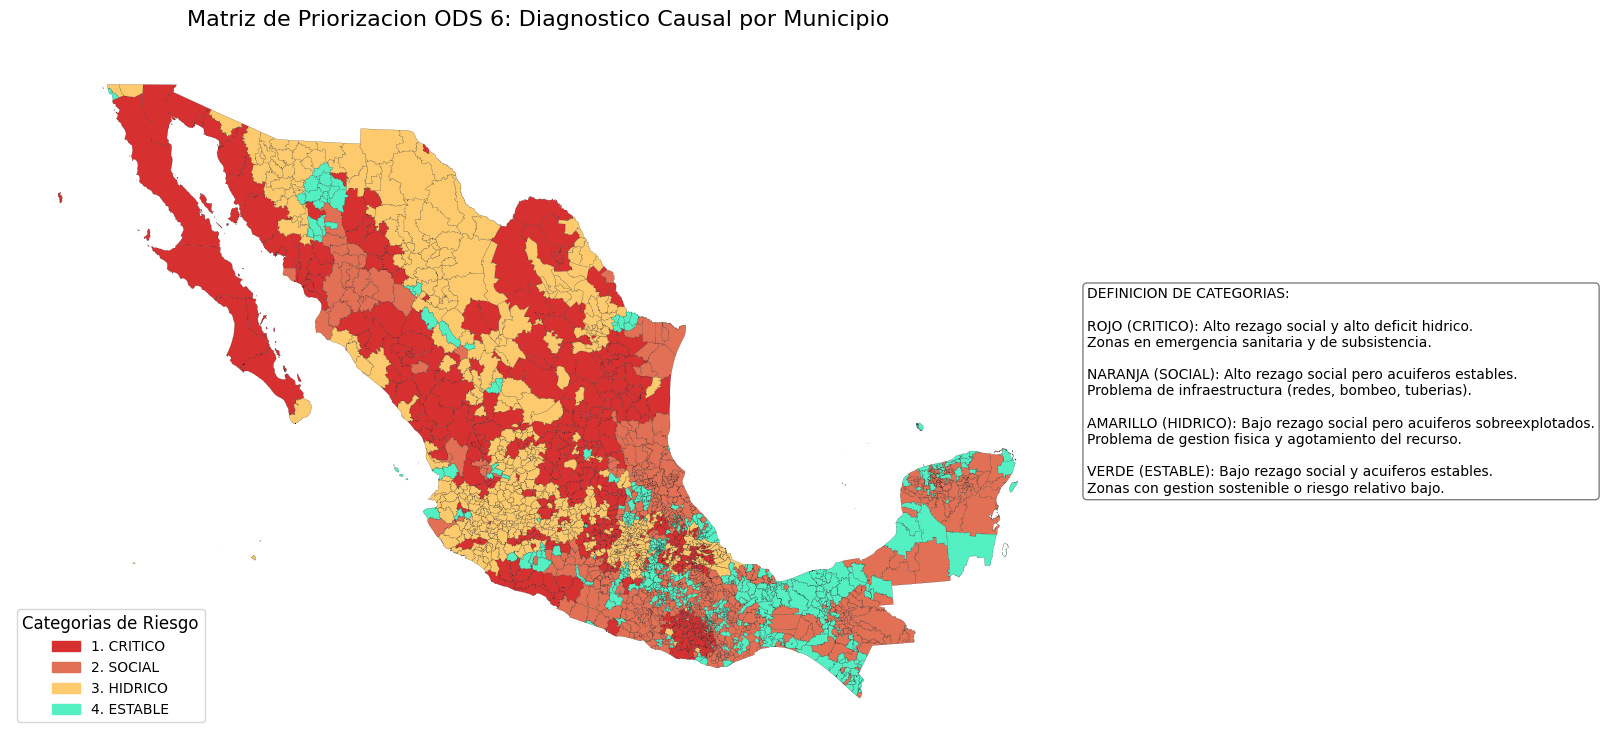

In [35]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. Calculo de umbrales estadisticos
umbral_agua = gdf_vulnerabilidad['DMA_NEGATI'].median()
umbral_pobreza = gdf_vulnerabilidad['Índice de rezago social'].median()

# 2. Funcion de categorizacion tecnica
def categorizar_prioridad(row):
    if row['DMA_NEGATI'] < umbral_agua and row['Índice de rezago social'] > umbral_pobreza:
        return '1. CRITICO'
    elif row['DMA_NEGATI'] >= umbral_agua and row['Índice de rezago social'] > umbral_pobreza:
        return '2. SOCIAL'
    elif row['DMA_NEGATI'] < umbral_agua and row['Índice de rezago social'] <= umbral_pobreza:
        return '3. HIDRICO'
    else:
        return '4. ESTABLE'

gdf_vulnerabilidad['categoria_prioridad'] = gdf_vulnerabilidad.apply(categorizar_prioridad, axis=1)

# 3. Configuracion visual del mapa
fig, ax = plt.subplots(figsize=(16, 10))

colores = {
    '1. CRITICO': '#d63031',    # Rojo
    '2. SOCIAL': '#e17055',     # Naranja/Coral
    '3. HIDRICO': '#fdcb6e',    # Amarillo/Dorado
    '4. ESTABLE': '#55efc4'     # Verde/Menta
}

# Dibujar el fondo y cada categoria
gdf_vulnerabilidad.plot(ax=ax, color='#f2f2f2', edgecolor='#d1d1d1', linewidth=0.1)

for cat, color in colores.items():
    subset = gdf_vulnerabilidad[gdf_vulnerabilidad['categoria_prioridad'] == cat]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor='black', linewidth=0.1)

# 4. Creacion de Leyenda Manual (Cuadros de color)
parches = [mpatches.Patch(color=c, label=l) for l, c in colores.items()]
ax.legend(handles=parches, title="Categorias de Riesgo", loc='lower left', fontsize=10, title_fontsize=12)

# 5. Cuadro de texto con el significado tecnico
texto_explicativo = (
    "DEFINICION DE CATEGORIAS:\n\n"
    "ROJO (CRITICO): Alto rezago social y alto deficit hidrico.\n"
    "Zonas en emergencia sanitaria y de subsistencia.\n\n"
    "NARANJA (SOCIAL): Alto rezago social pero acuiferos estables.\n"
    "Problema de infraestructura (redes, bombeo, tuberias).\n\n"
    "AMARILLO (HIDRICO): Bajo rezago social pero acuiferos sobreexplotados.\n"
    "Problema de gestion fisica y agotamiento del recurso.\n\n"
    "VERDE (ESTABLE): Bajo rezago social y acuiferos estables.\n"
    "Zonas con gestion sostenible o riesgo relativo bajo."
)

# Colocamos el texto a la derecha del mapa
plt.text(1.02, 0.5, texto_explicativo, transform=ax.transAxes, fontsize=10,
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.title("Matriz de Priorizacion ODS 6: Diagnostico Causal por Municipio", fontsize=16, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

In [36]:
# 1. Resumen estadistico por categoria
tablero_impacto = gdf_vulnerabilidad.groupby('categoria_prioridad').agg({
    'cve_geo_mun': 'count',
    'Poblacion total': 'sum',
    'DMA_NEGATI': 'sum'
}).rename(columns={
    'cve_geo_mun': 'Num_Municipios',
    'Poblacion total': 'Poblacion_Afectada',
    'DMA_NEGATI': 'Deficit_Hidrico_Total'
})

# 2. Calculo de porcentajes poblacionales
total_pob = tablero_impacto['Poblacion_Afectada'].sum()
tablero_impacto['%_Poblacion_Nacional'] = (tablero_impacto['Poblacion_Afectada'] / total_pob * 100).round(2)

print("--- TABLERO DE CONTROL: IMPACTO POR CATEGORIA ---")
display(tablero_impacto)

--- TABLERO DE CONTROL: IMPACTO POR CATEGORIA ---


,Num_Municipios,Poblacion_Afectada,Deficit_Hidrico_Total,%_Poblacion_Nacional
categoria_prioridad,,,,
1. CRITICO,475,25306310,-18400.534071,20.13
2. SOCIAL,753,18056674,0.000000,14.37
3. HIDRICO,661,64863590,-58718.095290,51.61
4. ESTABLE,567,17464003,0.000000,13.89


In [37]:
# 1. Filtrar municipios en estado critico
df_critico = gdf_vulnerabilidad[gdf_vulnerabilidad['categoria_prioridad'].str.contains('CRITICO')].copy()

# 2. Seleccionar los 15 con mayor poblacion
top_15_urgencia = df_critico.sort_values(by='Poblacion total', ascending=False).head(15)

print("--- TOP 15 MUNICIPIOS: PRIORIDAD DE INTERVENCION INMEDIATA ---")
display(top_15_urgencia[['NOM_MUN', 'NOM_EDO', 'Poblacion total', 'Índice de rezago social', 'DMA_NEGATI']])

--- TOP 15 MUNICIPIOS: PRIORIDAD DE INTERVENCION INMEDIATA ---


,NOM_MUN,NOM_EDO,Poblacion total,Índice de rezago social,DMA_NEGATI
1681,Puebla,Puebla,1692181,16.343901,-60.656614
713,Nezahualcóyotl,México,1077208,66.677643,-480.429914
12,Mexicali,Baja California,1049792,28.945835,-432.044272
1917,Hermosillo,Sonora,936263,14.435541,-74.253541
1839,San Luis Potosí,San Luis Potosí,911908,15.254196,-59.608014
61,Saltillo,Coahuila de Zaragoza,879958,19.489195,-69.670040
366,Acapulco de Juárez,Guerrero,779566,27.907672,-2.575047
273,Álvaro Obregón,Ciudad de México,759137,36.127318,-480.429914
285,Durango,Durango,688697,19.158745,-45.858625
759,Tlalnepantla de Baz,México,672202,15.043017,-480.429914


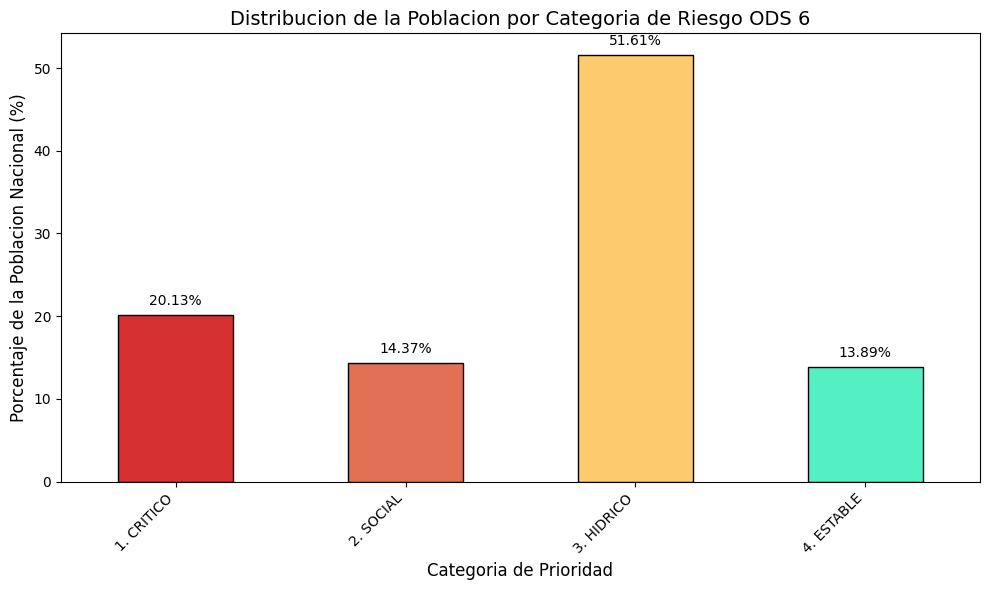

In [38]:
# 1. Configuracion de la grafica
plt.figure(figsize=(10, 6))
colores_lista = ['#d63031', '#e17055', '#fdcb6e', '#55efc4']

# 2. Graficar porcentaje de poblacion
ax = tablero_impacto['%_Poblacion_Nacional'].plot(kind='bar', color=colores_lista, edgecolor='black')

# 3. Personalizacion profesional
plt.title('Distribucion de la Poblacion por Categoria de Riesgo ODS 6', fontsize=14)
plt.ylabel('Porcentaje de la Poblacion Nacional (%)', fontsize=12)
plt.xlabel('Categoria de Prioridad', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Añadir etiquetas de valor sobre las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height()}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

In [39]:
# 1. Definicion de rutas de salida
ruta_salida_geojson = os.path.join(PROCESSED_DIR, "vulnerabilidad_final_analizada.geojson")
ruta_salida_csv = os.path.join(PROCESSED_DIR, "reporte_prioridades_ods6.csv")

# 2. Guardar como GeoJSON para conservar la geometria
gdf_vulnerabilidad.to_file(ruta_salida_geojson, driver='GeoJSON')

# 3. Guardar como CSV (sin geometria) para tablas de reportes o Excel
gdf_vulnerabilidad.drop(columns='geometry').to_csv(ruta_salida_csv, index=False, encoding='utf-8-sig')

print(f"Archivos guardados exitosamente en: {PROCESSED_DIR}")

Archivos guardados exitosamente en: C:\Users\Jafet\agua_vulnerabilidad_ods\notebook\..\data\processed
